<a href="https://colab.research.google.com/github/MajorSohaib/Data_Science_journey/blob/main/week2_day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Loaded", df.shape)

Loaded (891, 12)


# DATA Cleaning

In [7]:
df = df.drop('Cabin', axis=1)

if 'Cabin' in df.columns:
  df = df.drop('Cabin', axis=1)

#fill missing age with median

df['Age'] = df['Age'].fillna(df['Age'].median())

#drop values where embarked is missing

df = df.dropna(subset=['Embarked'])

print("Print missing values after cleaning")
print(df.isnull().sum())

Print missing values after cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [8]:
def categorize_age(age):
  if pd.isna(age):
    return 'Unknown'
  elif age<18:
    return 'Child'
  elif age<35:
    return 'Young Adult'
  elif age<60:
    return 'Adult'
  else:
    return 'Senior'

df['AgeCategory'] = df['Age'].apply(categorize_age)
print(df[['AgeCategory','Age' ]].head(10))


   AgeCategory   Age
0  Young Adult  22.0
1        Adult  38.0
2  Young Adult  26.0
3        Adult  35.0
4        Adult  35.0
5  Young Adult  28.0
6        Adult  54.0
7        Child   2.0
8  Young Adult  27.0
9        Child  14.0


In [10]:
#total passengers per age group
total_per_group = df.groupby('AgeCategory')['PassengerId'].count()

#total_per_group = df.groupby('AgeCategory')['PassengerId'].count()
survived_per_group = df.groupby('AgeCategory')['Survived'].sum()

died_per_group = total_per_group - survived_per_group

survival_rate = df.groupby('AgeCategory')['Survived'].mean() * 100

#combine into one table
summary = pd.DataFrame({
    'Total': total_per_group,
    'Survived':survived_per_group,
    'Died': died_per_group,
    'Survival rate': survival_rate.round(2)
})

print(summary)

             Total  Survived  Died  Survival rate
AgeCategory                                      
Adult          208        86   122          41.35
Child          113        61    52          53.98
Senior          25         6    19          24.00
Young Adult    543       187   356          34.44


## Bonus Analysis: Who Could Have Been Saved?

Focus on youth and children survival:
- 52 children died despite having highest survival rate (54%)
- 356 young adults died — largest group of casualties
- Combined 408 young people lost their lives
- Better evacuation prioritization could have saved more youth
- Seniors had lowest survival rate (24%) suggesting elderly
  were not adequately assisted during evacuation

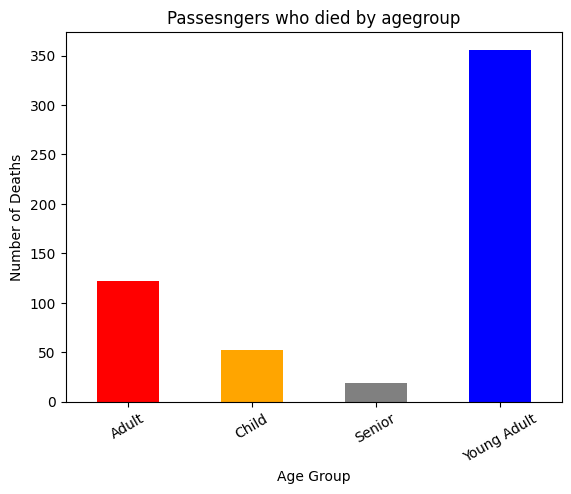

In [14]:
#charts who could have been saved
summary['Died'].plot(kind='bar', color=['red', 'orange', 'gray', 'blue'])
plt.title('Passesngers who died by agegroup')
plt.xlabel('Age Group')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=30)
plt.show()

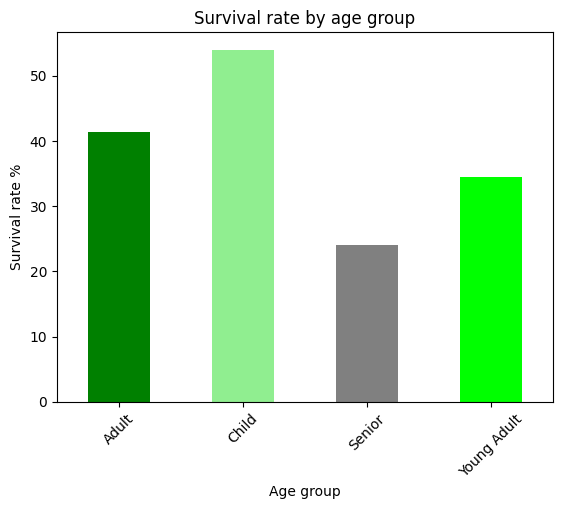

In [15]:
#Survival rate by age group
summary['Survival rate'].plot(kind='bar', color=['green', 'lightgreen', 'gray', 'lime'])
plt.title('Survival rate by age group')
plt.xlabel('Age group')
plt.ylabel('Survival rate %')
plt.xticks(rotation=45)
plt.show()